# Milestone 2 — From Power Flow Tables to Graph Datasets

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds
from torch_geometric.loader import DataLoader

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "m2"
STATS_DIR = ROOT / "results" / "m2_stats"
for d in [PROC_DIR, FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ALL_GRIDS = ["case24", "case30", "case118", "case39"]
GRID_COLORS = {"case24": "#4269D0", "case30": "#EFB118", "case118": "#FF725C", "case39": "#6CC5B0"}
SEED = 42
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Step 1 — BaseMVA normalization

case24      660.0
case30       66.4
case118     497.4
case39     1100.0


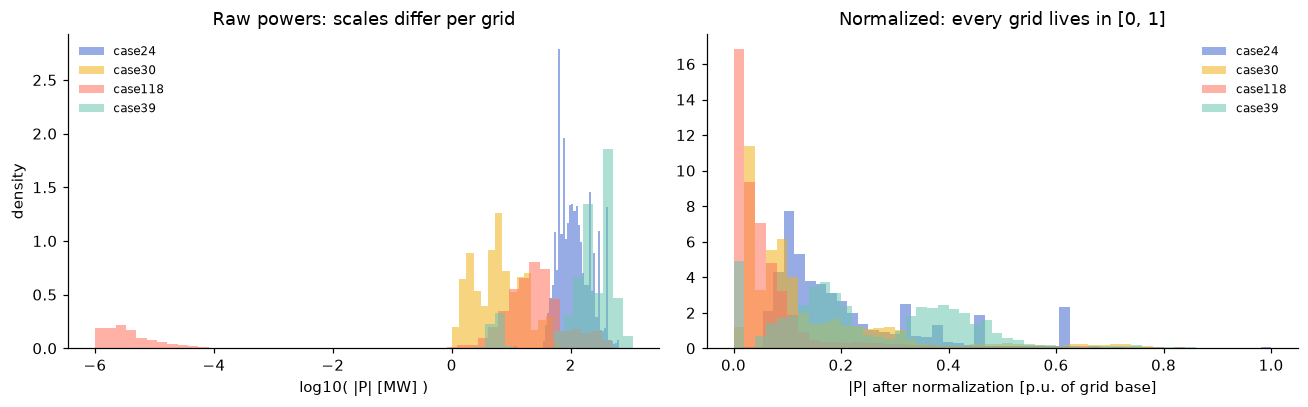

In [2]:
raw_nodes = {g: pd.read_csv(RAW_DIR / g / "node_features.csv") for g in ALL_GRIDS}
base_mva = {g: ds.compute_base_mva(raw_nodes[g]) for g in ALL_GRIDS}
print(pd.Series(base_mva, name="base MVA per grid").round(1).to_string())
with open(STATS_DIR / "base_mva.json", "w") as f:
    json.dump(base_mva, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for g in ALL_GRIDS:
    p = raw_nodes[g][["Pd", "Pg"]].abs().values.ravel()
    p = p[p > 1e-6]
    axes[0].hist(np.log10(p), bins=50, alpha=0.55, color=GRID_COLORS[g], label=g, density=True)
    axes[1].hist(p / base_mva[g], bins=50, alpha=0.55, color=GRID_COLORS[g], label=g, density=True)
axes[0].set(xlabel="log10( |P| [MW] )", ylabel="density", title="Raw powers: scales differ per grid")
axes[1].set(xlabel="|P| after normalization [p.u. of grid base]",
            title="Normalized: every grid lives in [0, 1]")
for a in axes:
    a.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_normalization.png", bbox_inches="tight")
plt.show()

## Step 2 — Building the graph objects

In [3]:
t0 = time.time()
graphs, bases = {}, {}
for g in ALL_GRIDS:
    graphs[g], bases[g] = ds.build_graphs(RAW_DIR, g)
    print("%-8s %4d graphs | base %7.1f MVA" % (g, len(graphs[g]), bases[g]))
print("total build time %.1fs" % (time.time() - t0))
print("\nexample object (case30, first scenario):")
print(graphs["case30"][0])

case24   1865 graphs | base   660.0 MVA


case30   1725 graphs | base    66.4 MVA


case118  1887 graphs | base   497.4 MVA


case39   1223 graphs | base  1100.0 MVA
total build time 10.0s

example object (case30, first scenario):
Data(x=[30, 9], edge_index=[2, 82], edge_attr=[82, 2], ybus_index=[2, 112], ybus_g=[112], ybus_b=[112], scenario=2000, group=500, scale=0.7411482950466765, n_removed=0, base_mva=66.43047185345874)


## Step 3 — Normalization preserves physics

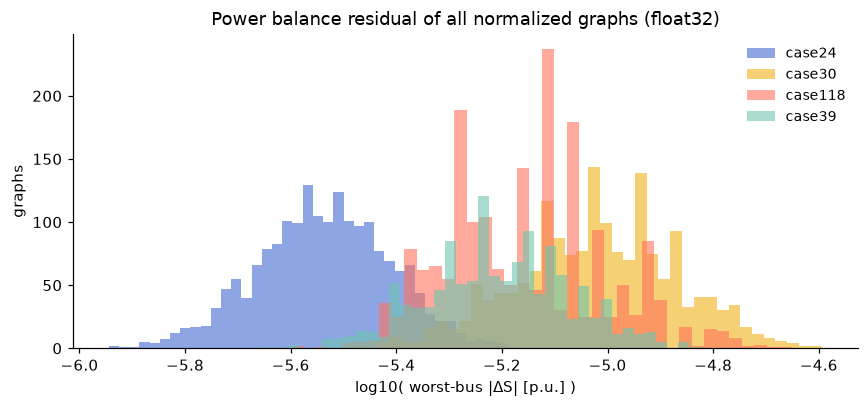

case24   worst residual: 6.74e-06 p.u.  (= 4.45e-03 MVA)
case30   worst residual: 2.55e-05 p.u.  (= 1.69e-03 MVA)
case118  worst residual: 2.23e-05 p.u.  (= 1.11e-02 MVA)
case39   worst residual: 1.50e-05 p.u.  (= 1.65e-02 MVA)


In [4]:
worst = {g: [] for g in ALL_GRIDS}
for g in ALL_GRIDS:
    loader = DataLoader(graphs[g], batch_size=256, shuffle=False)
    for batch in loader:
        dp, dq = ds.pbe_residual(batch.x, batch.ybus_index, batch.ybus_g, batch.ybus_b)
        s = torch.sqrt(dp**2 + dq**2)
        # max per graph in the batch
        for k in range(batch.num_graphs):
            m = batch.batch == k
            worst[g].append(float(s[m].max()))

fig, ax = plt.subplots(figsize=(8, 3.8))
for g in ALL_GRIDS:
    ax.hist(np.log10(np.array(worst[g]) + 1e-12), bins=40, alpha=0.6,
            color=GRID_COLORS[g], label=g)
ax.set(xlabel="log10( worst-bus |ΔS| [p.u.] )", ylabel="graphs",
       title="Power balance residual of all normalized graphs (float32)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_physics_after_norm.png", bbox_inches="tight")
plt.show()
for g in ALL_GRIDS:
    print("%-8s worst residual: %.2e p.u.  (= %.2e MVA)" %
          (g, max(worst[g]), max(worst[g]) * bases[g]))

## Step 4 — The masking strategy on real data

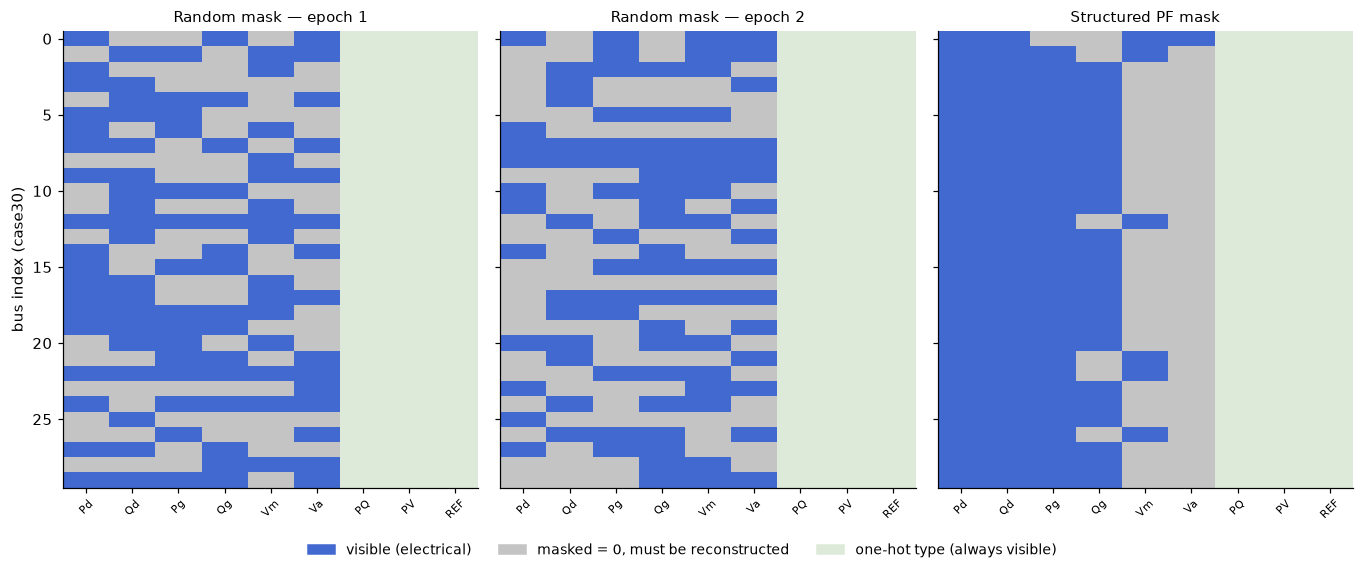

hidden electrical entries: epoch1 46.1%, epoch2 51.1% | PF mask hides exactly 2 per bus


In [5]:
x0 = graphs["case30"][0].x
gen1, gen2 = torch.Generator().manual_seed(1), torch.Generator().manual_seed(2)
_, m1 = ds.random_mask(x0, generator=gen1)
_, m2 = ds.random_mask(x0, generator=gen2)
_, m3 = ds.pf_mask(x0)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 5.2), sharey=True)
titles = ["Random mask — epoch 1", "Random mask — epoch 2", "Structured PF mask"]
for ax, m, ti in zip(axes, [m1, m2, m3], titles):
    img = np.zeros(m.shape)
    img[:, :6] = 1.0                # electrical, visible
    img[m.numpy()] = 2.0            # masked
    img[:, 6:] = 0.5                # one-hot columns (never masked)
    ax.imshow(img, cmap=plt.matplotlib.colors.ListedColormap(
        ["#DDE9D9", "#4269D0", "#C4C4C4"]), aspect="auto", vmin=0, vmax=2)
    ax.set_xticks(range(9)); ax.set_xticklabels(ds.NODE_FEATURES, fontsize=7, rotation=45)
    ax.set_title(ti, fontsize=10)
axes[0].set_ylabel("bus index (case30)")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="#4269D0", label="visible (electrical)"),
                    Patch(color="#C4C4C4", label="masked = 0, must be reconstructed"),
                    Patch(color="#DDE9D9", label="one-hot type (always visible)")],
           loc="lower center", ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(FIG_DIR / "f3_masking_real_data.png", bbox_inches="tight")
plt.show()
print("hidden electrical entries: epoch1 %.1f%%, epoch2 %.1f%% | PF mask hides exactly %d per bus"
      % (100 * m1[:, :6].float().mean(), 100 * m2[:, :6].float().mean(),
         int(m3.sum(1).unique())))

## Step 5 — Train / validation / test splits

case24   {'train': 1492, 'val': 187, 'test': 186}


case30   {'train': 1369, 'val': 174, 'test': 182}


case118  {'train': 1513, 'val': 186, 'test': 188}


case39   {'train': 977, 'val': 126, 'test': 120}


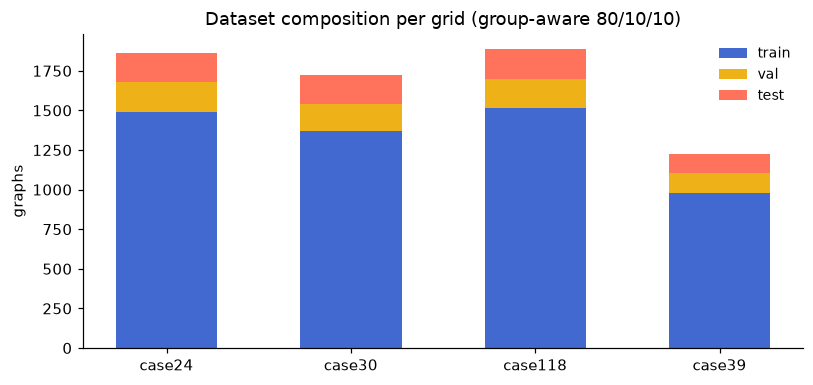

In [6]:
split_counts = {}
for g in ALL_GRIDS:
    splits = ds.split_graphs(graphs[g], seed=SEED)
    ds.save_processed(splits, PROC_DIR, g)
    split_counts[g] = {k: len(v) for k, v in splits.items()}
    print("%-8s" % g, split_counts[g])
with open(STATS_DIR / "split_counts.json", "w") as f:
    json.dump(split_counts, f, indent=2)

sc = pd.DataFrame(split_counts).T[["train", "val", "test"]]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bottom = np.zeros(len(sc))
for split, col in zip(["train", "val", "test"], ["#4269D0", "#EFB118", "#FF725C"]):
    ax.bar(sc.index, sc[split], bottom=bottom, label=split, color=col, width=0.55)
    bottom += sc[split].values
ax.set(ylabel="graphs", title="Dataset composition per grid (group-aware 80/10/10)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f4_splits.png", bbox_inches="tight")
plt.show()

## Step 6 — Multi-grid batching

In [7]:
mixed = graphs["case24"][:3] + graphs["case30"][:3] + graphs["case118"][:3]
batch = next(iter(DataLoader(mixed, batch_size=9, shuffle=False)))
print(batch)
dp, dq = ds.pbe_residual(batch.x, batch.ybus_index, batch.ybus_g, batch.ybus_b)
print("mixed-grid batch (24+30+118 buses): worst residual %.2e p.u. -> physics intact" %
      float(torch.sqrt(dp**2 + dq**2).max()))

DataBatch(x=[516, 9], edge_index=[2, 1572], edge_attr=[1572, 2], ybus_index=[2, 2024], ybus_g=[2024], ybus_b=[2024], scenario=[9], group=[9], scale=[9], n_removed=[9], base_mva=[9], batch=[516], ptr=[10])
mixed-grid batch (24+30+118 buses): worst residual 8.12e-06 p.u. -> physics intact
